In [40]:
using Pkg
Pkg.activate("C:/Users/av589/Desktop/Julia/ants")
using Plots
using DifferentialEquations
using LaTeXStrings
using NLsolve
using IntervalArithmetic, IntervalArithmetic.Symbols, IntervalRootFinding
using LinearAlgebra

  Activating project at `C:\Users\av589\Desktop\Julia\ants`


In [41]:
pythonplot()

Plots.PythonPlotBackend()

In [74]:
function model_3d_t(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n)=p
    S,C,T = x
    B = 1 - S - C - T
    Sdot = -(alphaC+alphaB+alphaT)*S + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n)
    Cdot = alphaC*S - omegaC*C/(1+ (C/k)^n)
    Tdot = alphaT*S - beta*T
    Coutdot =  omegaC*C/(1+ (C/k)^n)
    Toutdot =  beta*T
    Boutdot = omegaB*B/(1+ (C/k)^n)
    [
        Sdot
        Cdot
        Tdot
        Coutdot
        Toutdot
        Boutdot
    ]
end

function model_6d_t(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau)=p
    #print("bug")
    S,C,T,xC,xB,xT = x
    B = 1 - S - C - T
    Sdot = -(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n)
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C)))
    xBdot = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C)))
    xTdot = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C)))
    Coutdot =  omegaC*C/(1+ (C/k)^n)
    Toutdot =  beta*T
    Boutdot = omegaB*B/(1+ (C/k)^n)
    [
        Sdot
        Cdot
        Tdot
        xCdot
        xBdot
        xTdot
        Coutdot
        Toutdot
        Boutdot
    ]
end

model_6d_t (generic function with 1 method)

In [76]:
pal = palette(:default)

In [ ]:
scalefontsizes(1.75)

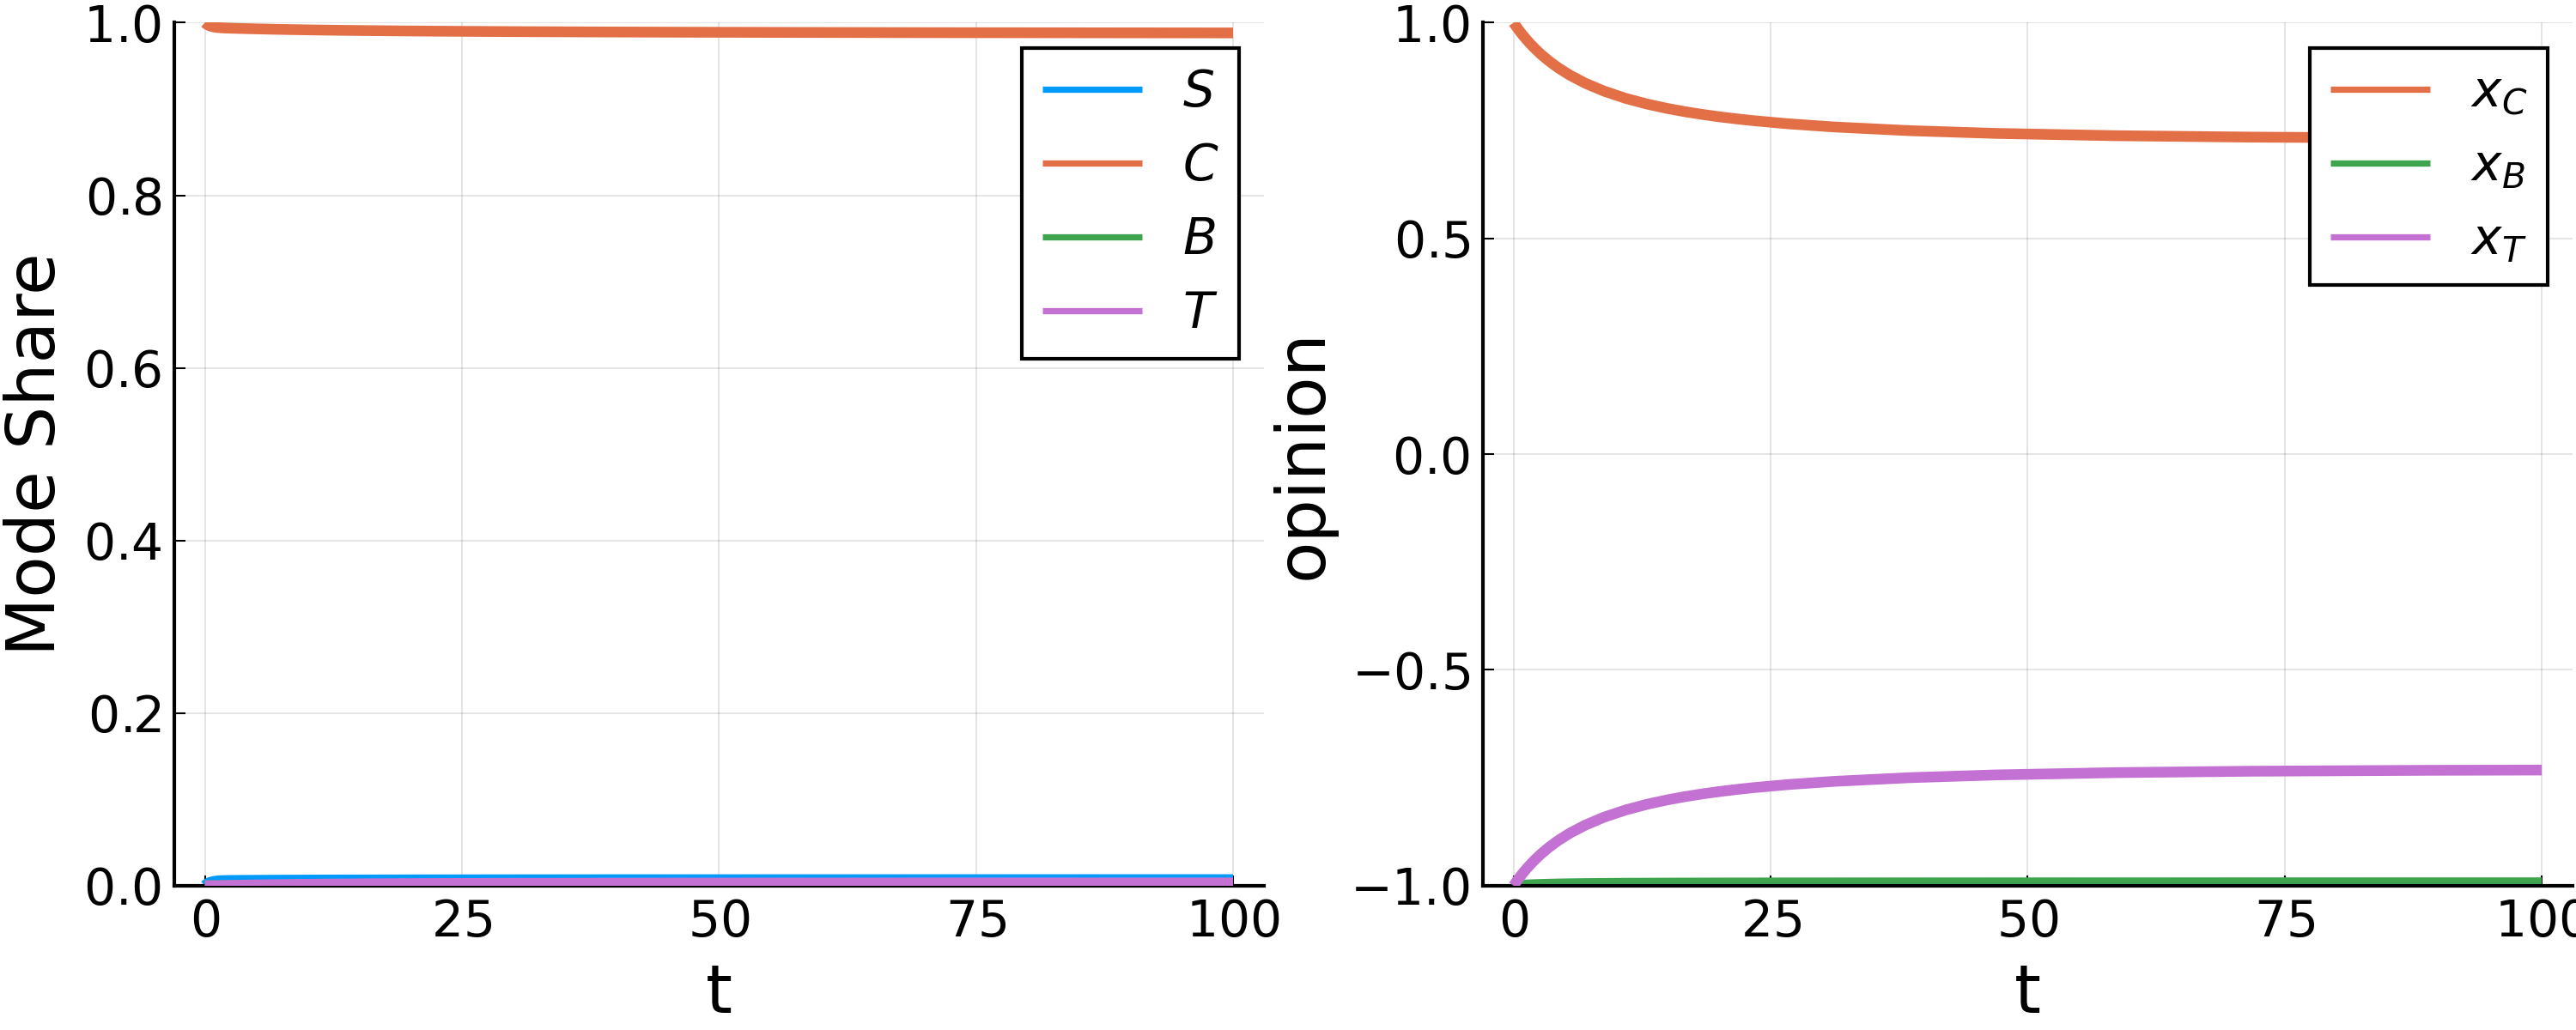

In [201]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.5,n=4,u=1.6,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau = par
u0 = [0.0,1.0,0.0,1.0, -1.0,-1.0,0.0,0.0,0.0]
tspan=(0.0,100.0)

prob_6d = ODEProblem(model_6d_t,u0,tspan,par)
sol6d = DifferentialEquations.solve(prob_6d)
S,C,T,xC,xB,xT,Ctot6,Btot6,Ttot6 = sol6d[1,:],sol6d[2,:],sol6d[3,:],sol6d[4,:],sol6d[5,:],sol6d[6,:],sol6d[7,:],sol6d[8,:],sol6d[9,:]
B = 1 .- S .- C .- T

pal = palette(:default)

p1 = plot(sol6d.t, vec(S), label = L"S",  lw=3, ylims=(0,1), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol6d.t, vec(C), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol6d.t, vec(B), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol6d.t, vec(T), label = L"T",   lw=3, color = pal[4])

p2 = plot(sol6d.t, vec(xC), label = L"x_C", lw=3, ylims=(-1,1), color = pal[2],xlabel ="t",ylabel = "opinion")
plot!(p2, sol6d.t, vec(xB), label = L"x_B", lw=3, color = pal[3])
plot!(p2, sol6d.t, vec(xT), label = L"x_T", lw=3, color = pal[4])

FIG = plot(p1, p2, size=(1000,400),dpi = 300)
#png(FIG,"SINGLE_unfolding")

In [184]:
xC[end],xB[end],xT[end]

(-0.6496444440159977, 0.4616642861182511, 0.6496444440177347)

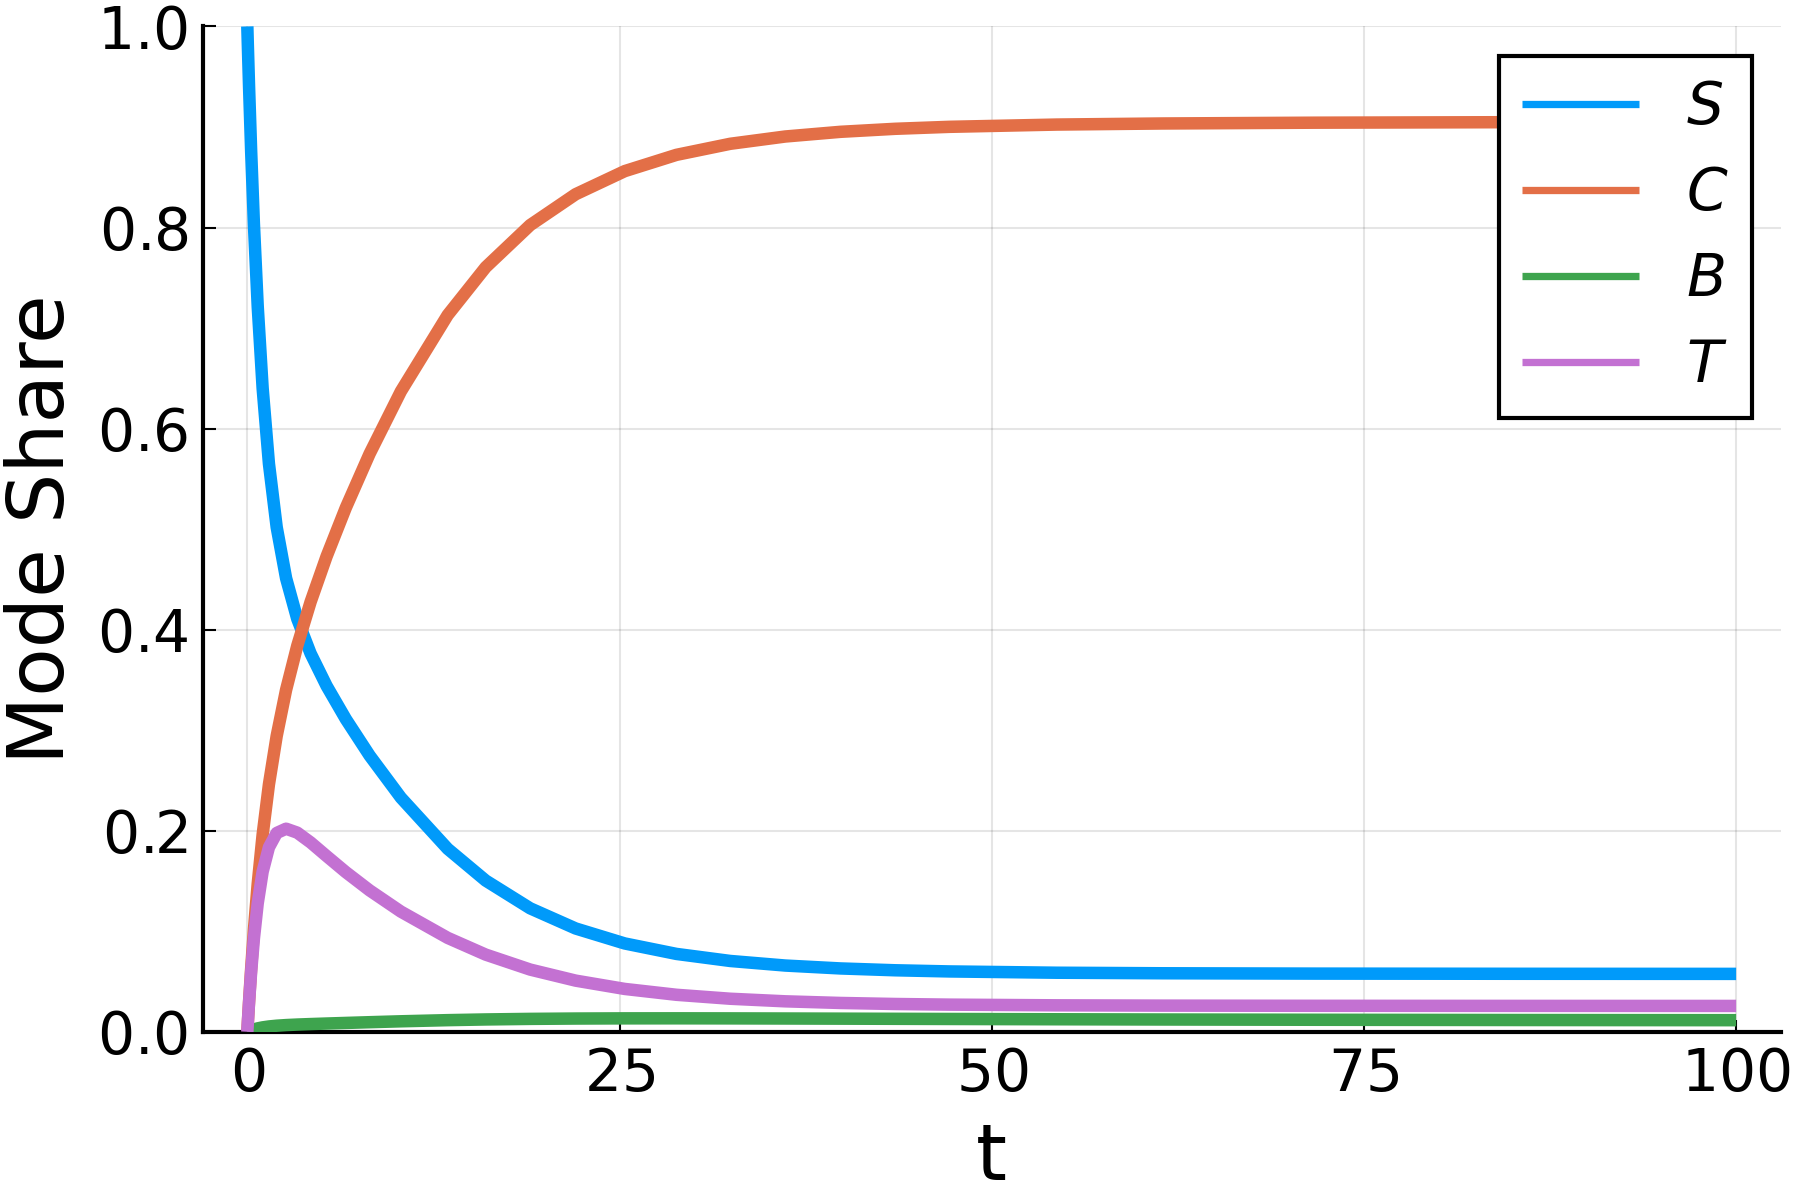

In [202]:
par = (alphaC=1-xC[end],alphaB=1.0+xB[end],alphaT=1.0+xT[end],beta=0.6,omegaC=0.2,omegaB=0.4,k=0.5,n=4)#,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 2)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n = par
u0 = [1.0,0,0,0,0,0]
tspan=(0.0,100.0)

prob_3d = ODEProblem(model_3d_t,u0,tspan,par)
sol3d = DifferentialEquations.solve(prob_3d)
S,C,T,Ctot3,Ttot3,Btot3 = sol3d[1,:],sol3d[2,:],sol3d[3,:],sol3d[4,:],sol3d[5,:],sol3d[6,:]
B = 1 .- S .- C .- T

pal = palette(:default)

p1 = plot(sol3d.t, vec(S), label = L"S",  lw=3, ylims=(0,1), color = pal[1],xlabel = "t",ylabel = "Mode Share")
plot!(p1, sol3d.t, vec(C), label = L"C",   lw=3, color = pal[2])
plot!(p1, sol3d.t, vec(B), label = L"B",   lw=3, color = pal[3])
plot!(p1, sol3d.t, vec(T), label = L"T",   lw=3, color = pal[4])

#p2 = plot(sol3d.t, vec(Ctot), label = L"C tot", lw=3, color = pal[2])
#plot!(p2, sol3d.t, vec(Btot), label = L"B tot", lw=3, color = pal[3])
#plot!(p2, sol3d.t, vec(Ttot), label = L"T tot", lw=3, color = pal[4])

FIG = plot(p1, size=(600,400),dpi=300)
#png(FIG,"Basic model")

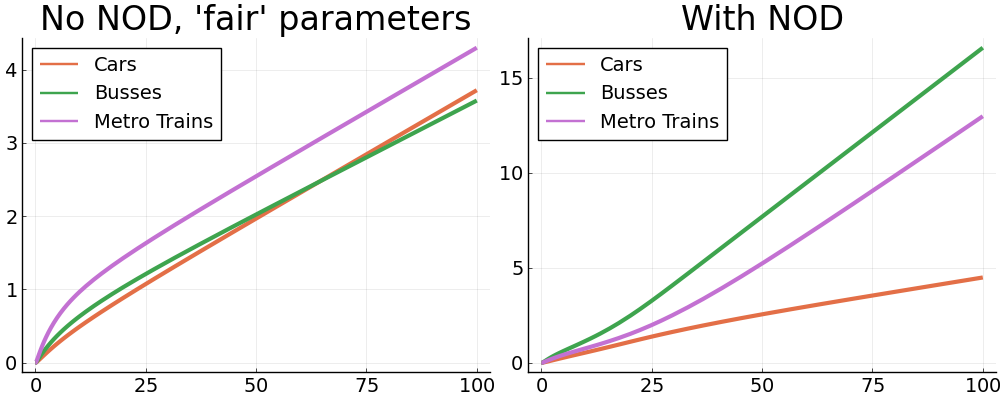

In [186]:
p3 = plot(sol3d.t, vec(Ctot3), label = "Cars", lw=3, color = pal[2],title = "No NOD, 'fair' parameters",legend=:topleft)
plot!(p3, sol3d.t, vec(Btot3), label = "Busses", lw=3, color = pal[3])
plot!(p3, sol3d.t, vec(Ttot3), label = "Metro Trains", lw=3, color = pal[4])

p4 = plot(sol6d.t, vec(Ctot6), label = "Cars", lw=3, color = pal[2], title = "With NOD",legend=:topleft)
plot!(p4, sol6d.t, vec(Btot6), label = "Busses", lw=3, color = pal[3])
plot!(p4, sol6d.t, vec(Ttot6), label = "Metro Trains", lw=3, color = pal[4])


FIG=plot(p3, p4, size=(1000,400))#,plot_title = "Total People Moved", plot_titlevspan=0.5,titlefont = 10)
#png(FIG,"Total Moved")

In [187]:
Tot_no_nod = Ctot3[end]+Btot3[end]+Ttot3[end]
Tot_with_nod = Ctot6[end]+Btot6[end]+Ttot6[end]
print(Tot_no_nod,"---",Tot_with_nod)

11.590944536906214---34.017835008188584

In [219]:
us = LinRange(0.01,2.5,100)
y = []
y1=[]
u06 = [1.0,0.0,0.0,0.0, 0.0,0.0,0.0,0.0,0.0]
u03 = [1.0,0,0,0,0,0]
tspan=(0.0,100.0)
for u in us
    par6 = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.5,n=4,u=u,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3)
    prob_6d = ODEProblem(model_6d_t,u06,tspan,par6)
    sol6d = DifferentialEquations.solve(prob_6d)
    Ctot6,Ttot6,Btot6 =sol6d[7,end],sol6d[8,end],sol6d[9,end]
    xCend,xBend,xTend = sol6d[4,end],sol6d[5,end],sol6d[6,end]
    par3 = (alphaC=1+xCend,alphaB=1.0+xBend,alphaT=1.0+xTend,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.5,n=4)
    prob_3d = ODEProblem(model_3d_t,u03,tspan,par3)
    sol3d = DifferentialEquations.solve(prob_3d)
    Ctot,Ttot,Btot = sol3d[4,end],sol3d[5,end],sol3d[6,end]
    tot_diff = (Ctot6 + Btot6 + Ctot6) - (Ctot+Btot+Ttot)
    push!(y,tot_diff)
    push!(y1,(Ctot6 + Btot6 + Ctot6))
    
end

In [220]:
us2 = LinRange(0.01,2.5,100)
y2 = []
u06 = [1.0,0.0,0.0,0.0, 0.0,0.0,0.0,0.0,0.0]
u03 = [1.0,0,0,0,0,0]
tspan=(0.0,100.0)
for u in us2
    par6 = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.5,n=4,u=u,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3)
    prob_6d = ODEProblem(model_6d_t,u06,tspan,par6)
    sol6d = DifferentialEquations.solve(prob_6d)
    Ctot6,Ttot6,Btot6 =sol6d[7,end],sol6d[8,end],sol6d[9,end]
    xCend,xBend,xTend = sol6d[4,end],sol6d[5,end],sol6d[6,end]
    par3 = (alphaC=1-xCend,alphaB=1.0+xBend,alphaT=1.0+xTend,beta=0.6,omegaC=0.2,omegaB=0.4,k=0.5,n=4)
    prob_3d = ODEProblem(model_3d_t,u03,tspan,par3)
    sol3d = DifferentialEquations.solve(prob_3d)
    Ctot,Ttot,Btot = sol3d[4,end],sol3d[5,end],sol3d[6,end]
    tot_diff = (Ctot6 + Btot6 + Ctot6) - (Ctot+Btot+Ttot)
    push!(y2,tot_diff)
    
end

In [226]:
p0= plot(us,y1, xlabel = L"u", title = "Total people moved with NOD",lw = 3,label = "")
p1 = plot(us,y,xlabel = L"u", title = "'fair' with NOD - without NOD",ylabel ="",label ="",lw = 3)
p2 = plot(us2,y2,xlabel = L"u", title = "'unfair' with NOD - without NOD",ylabel ="",label ="",lw = 3)
layout = @layout [a [b; c]]
FIG = plot(p0,p1,p2,plot_title = "title", size = (1400,600),dpi = 300,layout = layout)

png(FIG,"fair vs unfair")

"fair vs unfair.png"

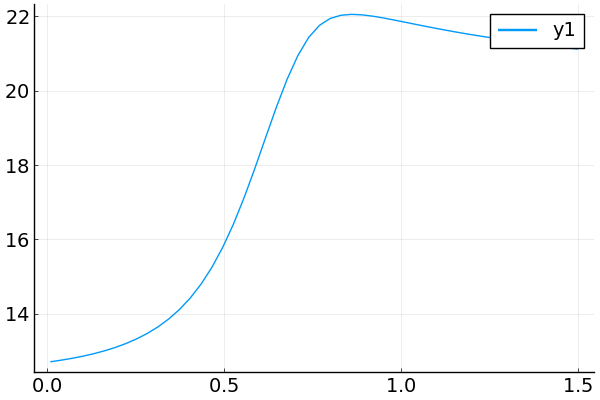